# Bonus Exploration

I decide to exlore the similarity between some development-related words (e.g. technology, wealth) and developed/developing countries. I suppose some words that usually appear with developed countreis are tend to have higher similarity with the country names; and words that usually appear with developing countries are tend to have higher similarity with these countries.

For comparision, I just use Word2Vec model. In order to get a stable, generalized result, I use pretrained models **Gensim Word2Vec (trained on Text8)** and **Gensim Word2Vec (trained on Google News)**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Load models
from gensim.models import KeyedVectors
# Gensim Word2Vec (trained on Text8)
with open('word2vec_gensim_embeddings.pkl', 'rb') as f:
    gsm_data = pickle.load(f)
gsm_embeddings = torch.as_tensor(gsm_data['embeddings'])
gsm_word2idx = gsm_data['word2idx']

# Gensim Word2Vec (trained on Google News)
google_model = KeyedVectors.load('word2vec-google-news-300.model')

In [2]:
# Funciton to get vector
def get_vec(word, embeddings, word2idx=None):
    if word2idx is not None:
        return embeddings[word2idx[word]]
    else:
        return embeddings[word]

This is the function to compute word vector similarity.

- Step 1: get word vector of each country
- Step 2: compute the average developed/developing country word vector to stand for commonality of developed/developing country
- Step 3: normalized `v1-v2` is the direction from developing country to developed country, which is the axis of our comparison
- Step 4: compute the dot similarity of a given word vector and the axis. The sign (direction) measures whether the word is closer to developed countries or developing countries. The length measures the appearance frequency of the word and country category.

In [3]:
def analyze_development_axis(countries, test_words, embeddings, word2idx=None):
    # Get developed and developing countries
    developed_countries = countries['developed_countries']
    developing_countries = countries['developing_countries']
    
    # compute average vectors
    vecs_1 = [get_vec(w, embeddings, word2idx) for w in developed_countries]
    vecs_2 = [get_vec(w, embeddings, word2idx) for w in developing_countries]

    v_1 = np.mean(vecs_1, axis=0)
    v_2 = np.mean(vecs_2, axis=0)
    
    # compute vector axis
    v_axis = v_1 - v_2
    v_axis_norm = v_axis / np.linalg.norm(v_axis)
    
    # compute projections
    results = []
    for word in test_words:
        v_w = get_vec(word, embeddings, word2idx)
        if v_w is not None:
            score = np.dot(v_w, v_axis_norm)
            results.append((word, score))
    
    # sort in descending order
    results.sort(key=lambda x: x[1], reverse=True)
    return results

This is a function to plot the result of the dot product, including direction(sign) and magnitude(score).

In [4]:
def plot_comparison(res_text8, res_google):
    words = [r[0] for r in res_google]
    scores_g = [r[1] for r in res_google]
    
    # 匹配 Text8 的分数（确保词汇一致）
    dict_t8 = dict(res_text8)
    scores_t8 = [dict_t8.get(w, 0) for w in words]

    x = np.arange(len(words))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(x - width/2, scores_t8, width, label='Text8 (100d)', color='skyblue')
    ax.barh(x + width/2, scores_g, width, label='Google News (300d)', color='salmon')

    ax.set_xlabel('Projection on Development Axis (Higher = More Developed)')
    ax.set_title('Comparison of Social Concept Projections')
    ax.set_yticks(x)
    ax.set_yticklabels(words)
    ax.legend()
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.show()

## First Trial

In [5]:
# Define some developed and developing countries
countries = {'developed_countries': ['usa', 'canada', 'uk', 'japan', 'germany'], 
             'developing_countries': ['china', 'india', 'brazil', 'vietnam', 'nigeria', 'kenya']}

# Some words that describe development-related concepts
test_words = [
        'technology', 'industry', 'wealth',
        'poverty', 'debt', 'agriculture',
        'education', 'healthcare'
    ]

In [6]:
results_text8 = analyze_development_axis(countries, test_words, gsm_embeddings, gsm_word2idx)
results_google = analyze_development_axis(countries, test_words, google_model, None)

C:\Users\Morry\AppData\Local\Temp\ipykernel_41264\2283228397.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  score = np.dot(v_w, v_axis_norm)


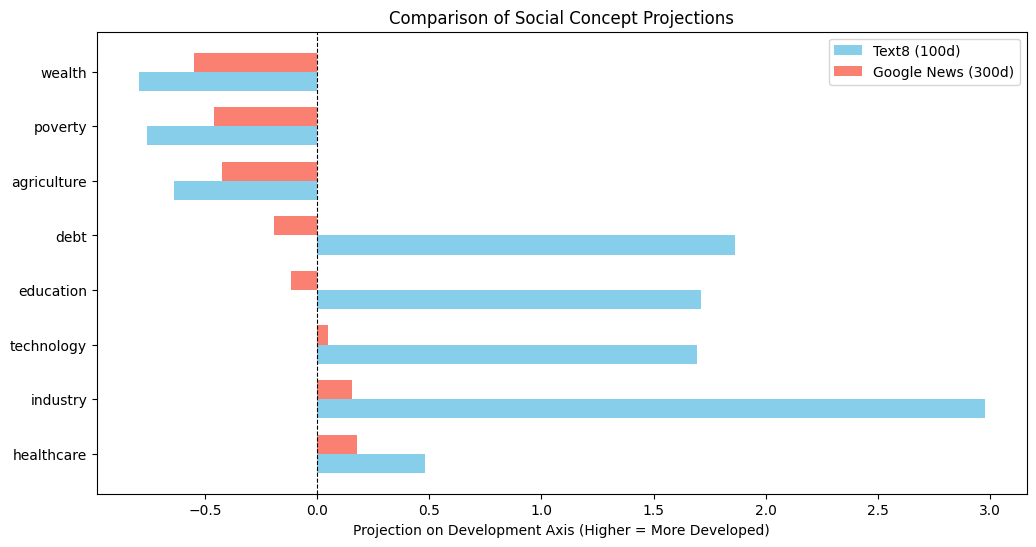

In [7]:
plot_comparison(results_text8, results_google)

The graph shows that different training data causes different result.

- In Text8, "debt", "education" are closer to developing counties; but in Google News, they are closer to developed countries.
- The magnitude of each word using different training data is different, but their relative magnitue is similar.

## Second Trial

We can see that in first trial, the magnitude of technology is not so large. So I pick out Chian, India and Brazil, for which these countries have relatively strong technologies, and add some developing countries in Africa to see whether this makes any difference.

C:\Users\Morry\AppData\Local\Temp\ipykernel_41264\2283228397.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  score = np.dot(v_w, v_axis_norm)


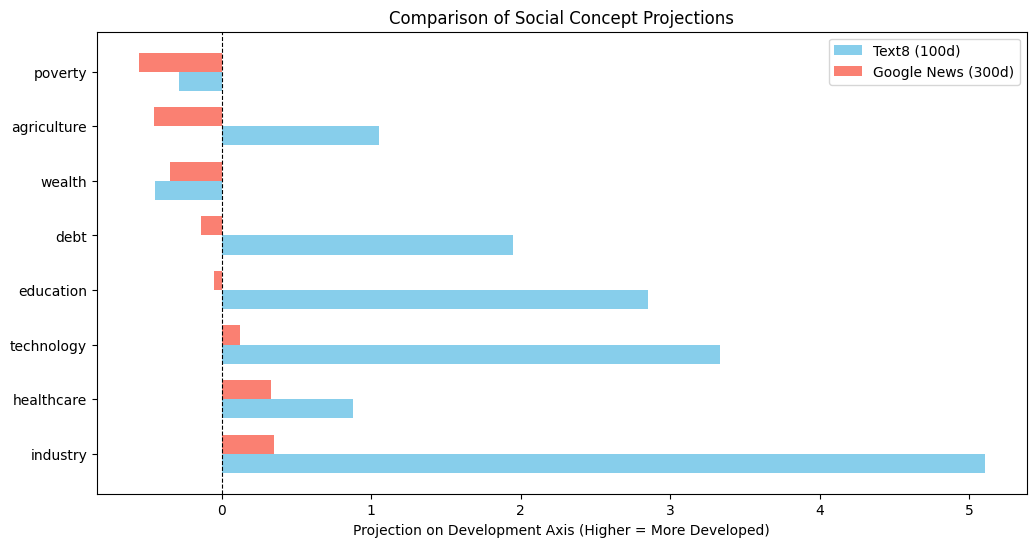

In [8]:
countries = {'developed_countries': ['usa', 'canada', 'uk', 'japan', 'germany'], 
             'developing_countries': ['vietnam', 'nigeria', 'kenya', 'ethiopia', 'sudan', 'uganda']}

results_text8 = analyze_development_axis(countries, test_words, gsm_embeddings, gsm_word2idx)
results_google = analyze_development_axis(countries, test_words, google_model, None)

plot_comparison(results_text8, results_google)

The Result is quite suprising as the magnitude of "technology" is still small.

If we use Text8:
- Directions: the same as before
- Score: has some change but not a lot

If we use Google News:
- Directions: agriculture turns positive
- Scores: has some change but not a lot